# User Notebook

## Introduction

This user notebook provides an overview of the core commands of the STL library for statistical scattering analysis. Its purpose is to guide users through the fundamental operations required to compute **scattering statistics** and **cross-statistics between channels**, for both **periodic** and **non-periodic** domains. Other basic statistical quantities such as **mean**, **variance**, and **power spectrum** are also available.

Beyond analysis, the library also supports **data synthesis** based on target statistics. This notebook demonstrates how to define **custom loss functions** that compare statistical descriptors, and how to **run optimization procedures** to generate signals or fields that match desired statistical properties.

Examples are provided to illustrate typical workflows and recommended usage patterns.

Note:

- For **2D kernel** data: **mean**, **variance**, and **scattering coefficients** can be computed (periodic or non-periodic data; with or without NaN values).

- For **2D FFT** data: **mean**, **variance**, **scattering coefficients**, and **power spectrum** can be computed (periodic or non-periodic data; NaN values are non handled).

In [ ]:
# Import useful libraries, test data path and STL modules

# Library imports
import numpy as np
import matplotlib.pyplot as plt
import torch

import os
import sys

from types import SimpleNamespace

# Add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.dirname(os.path.abspath(os.getcwd() + "../"))
sys.path.append(PARENT_DIR)
print("Parent directory added to sys.path:", ".../" + PARENT_DIR.split("//")[-1])

# Path to test data
DATA_TEST_PATH = PARENT_DIR + "/data" + "/test"
print("Dataset directory used:", ".../" + PARENT_DIR.split("/")[-1] + DATA_TEST_PATH.split(PARENT_DIR.split("/")[-1])[-1])

# STL package imports
from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch, WaveletOperator2Dkernel_torch
from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch, WaveletOperator2D_FFT_torch
from STL_main.Synthesis import optimize_scattering_LBFGS
from STL_main.torch_backend import _DEFAULT_DEVICE

print("Working on device:", _DEFAULT_DEVICE)

Parent directory added to sys.path: .../c:\Users\Danie\Bureau\STL-Dev
Dataset directory used: .../c:\Users\Danie\Bureau\STL-Dev/data/test
Working on device: cpu


In [6]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [83]:
# ----- Utils functions for visualization -----

# Plot and compare scattering coefficients of two ST data (e.g., Kernel vs FFT, with vs without NaN values, or with vs without PBC)
def plot_scattering_coeffs(
    st_data1,
    st_data2,
    suptitle,
    label_st_data1,
    label_st_data2
):
    plt.figure(figsize=(10, 8))

    # --- S1 ---
    plt.subplot(2,2,1)
    plt.plot(st_data1.S1.cpu().numpy().flatten(), color='b', label=label_st_data1)
    plt.plot(st_data2.S1.cpu().numpy().flatten(), color='r', label=label_st_data2, linewidth=0.7)
    plt.yscale('log')
    plt.title('S1')
    plt.legend()

    # --- S2 ---
    plt.subplot(2,2,2)
    plt.plot(st_data1.S2.cpu().numpy().flatten(), color='b', label=label_st_data1)
    plt.plot(st_data2.S2.cpu().numpy().flatten(), color='r', label=label_st_data2, linewidth=0.7)
    plt.yscale('log')
    plt.title('S2')
    plt.legend()

    # --- S3 ---
    plt.subplot(2,2,3)
    plt.plot(st_data1.S3.abs().cpu().numpy().flatten(), color='b', label=label_st_data1)
    plt.plot(st_data2.S3.abs().cpu().numpy().flatten(), color='r', label=label_st_data2, linewidth=0.7)
    plt.yscale('log')
    plt.title('S3')
    plt.legend()

    # --- S4 ---
    plt.subplot(2,2,4)
    plt.plot(st_data1.S4.abs().cpu().numpy().flatten(), color='b', label=label_st_data1)
    plt.plot(st_data2.S4.abs().cpu().numpy().flatten(), color='r', label=label_st_data2, linewidth=0.7)
    plt.yscale('log')
    plt.title('S4')
    plt.legend()

    plt.suptitle(suptitle, fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    plt.show()  

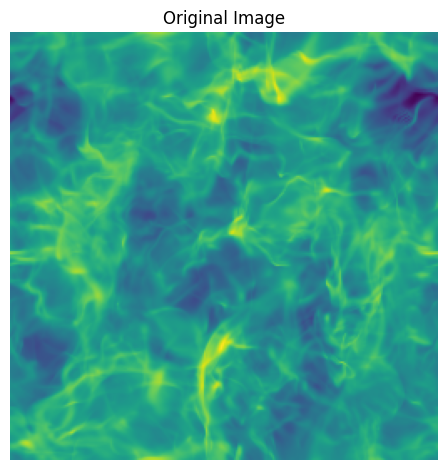

In [94]:
# Image loading
im = np.load(DATA_TEST_PATH + "/" + 'Turb_6.npy')[:, None, :, :] # [Nb, Nc, Nx, Ny]

# Visualize loaded data
plt.imshow(im[0, 0, :, :])
plt.title("Original Image")
plt.axis('off')
plt.tight_layout()
plt.show()

## Scattering Coefficients Computation

| PBC | Mask (NaNs) | Channel(s) | Comparison Statistics |
|-----|-------------|---------|-----------------------|
| PBC image | No mask | Mono + Cross | Kernel vs FFT |
| non-PBC image | No mask | Mono | (PBC vs non-PBC) - Kernel + FFT|
| PBC image | Mask | Mono | (mask vs no mask) - Kernel |


### 1. PBC - No Mask

#### 1.1 Mono Channel (Kernel vs FFT)

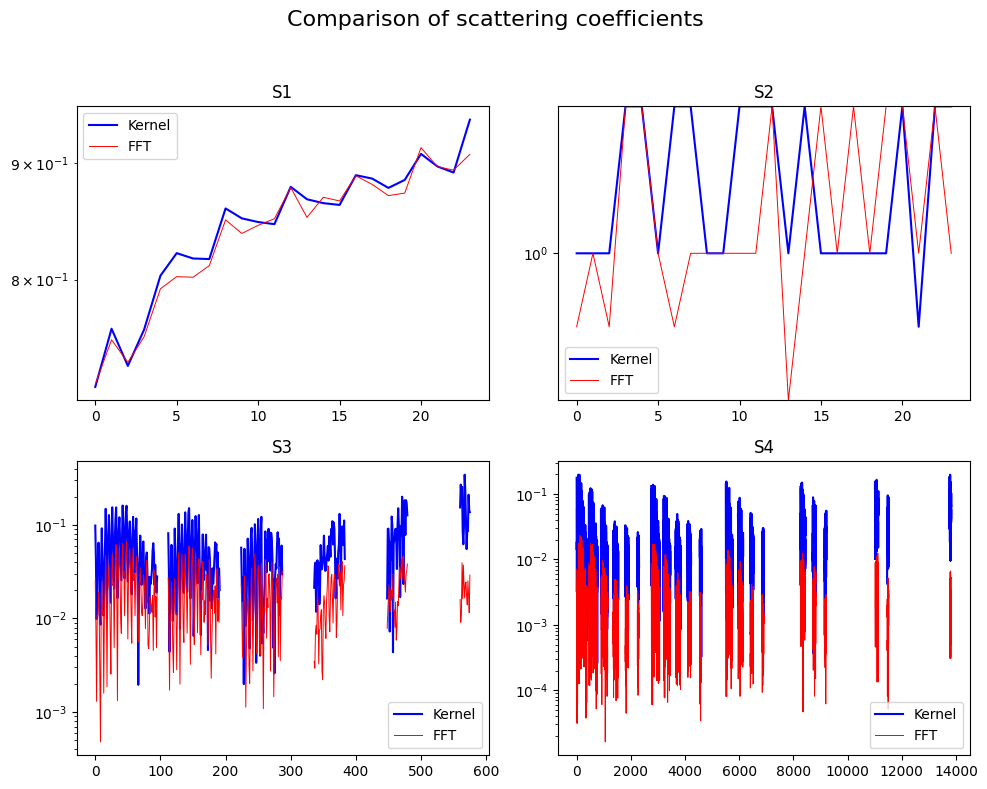

In [97]:
im_mono_channel = im[0, 0, :, :]

# Instantiate kernel and FFT dataclass on the mono-channel image
data_kernel = STL_2D_Kernel_Torch(im_mono_channel, pbc=True)
data_fft = STL_2D_FFT_Torch(im_mono_channel, pbc=True)

# Get ST operator
st_op_kernel = data_kernel.get_ST_op()
st_op_fft = data_fft.get_ST_op()

# Apply
st_data_kernel = st_op_kernel.apply(data_kernel)
st_data_fft = st_op_fft.apply(data_fft)

# Plot and compare scattering coefficients of the two ST data
plot_scattering_coeffs(
    st_data_kernel,
    st_data_fft,
    suptitle="Comparison of scattering coefficients",
    label_st_data1="Kernel",
    label_st_data2="FFT"
)

#### 1.2 Cross Channels (Kernel vs FFT)

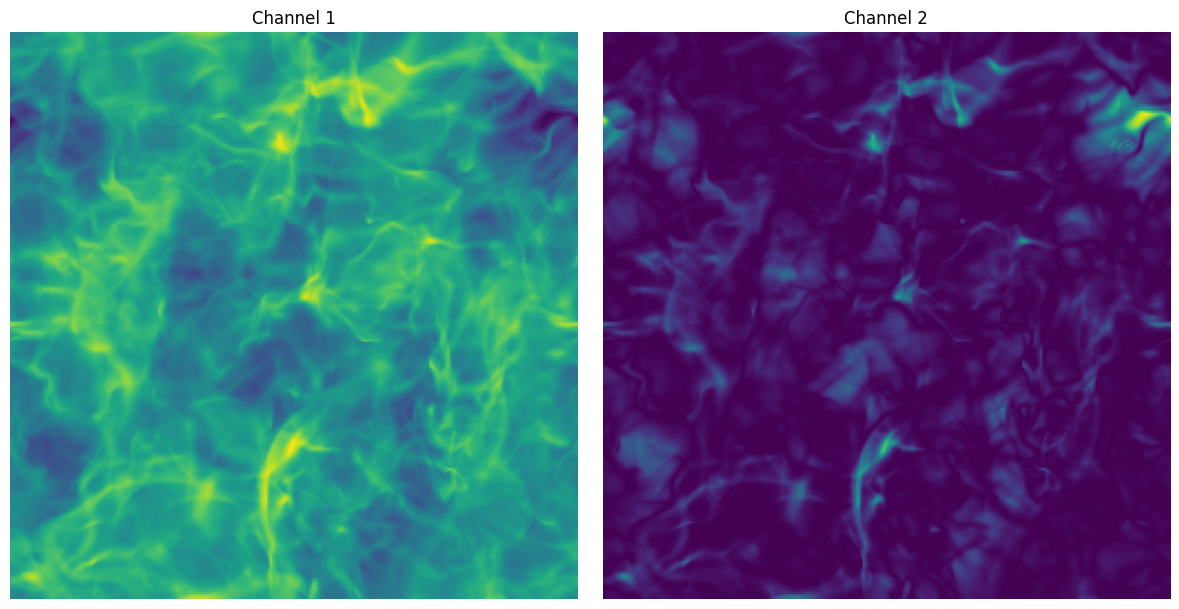

In [71]:
im_multi_channel = np.stack([im[0, 0, :, :], (im[0, 0, :, :]-im[0,0, :, :].mean(keepdims=True))**2])
im_multi_channel -= im_multi_channel.mean(axis=(1,2), keepdims=True)

# Visualize each channel of the multi-channel image
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(im_multi_channel[0], cmap='viridis')
plt.title("Channel 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(im_multi_channel[1], cmap='viridis')
plt.title("Channel 2")
plt.axis("off")

plt.tight_layout()
plt.show()

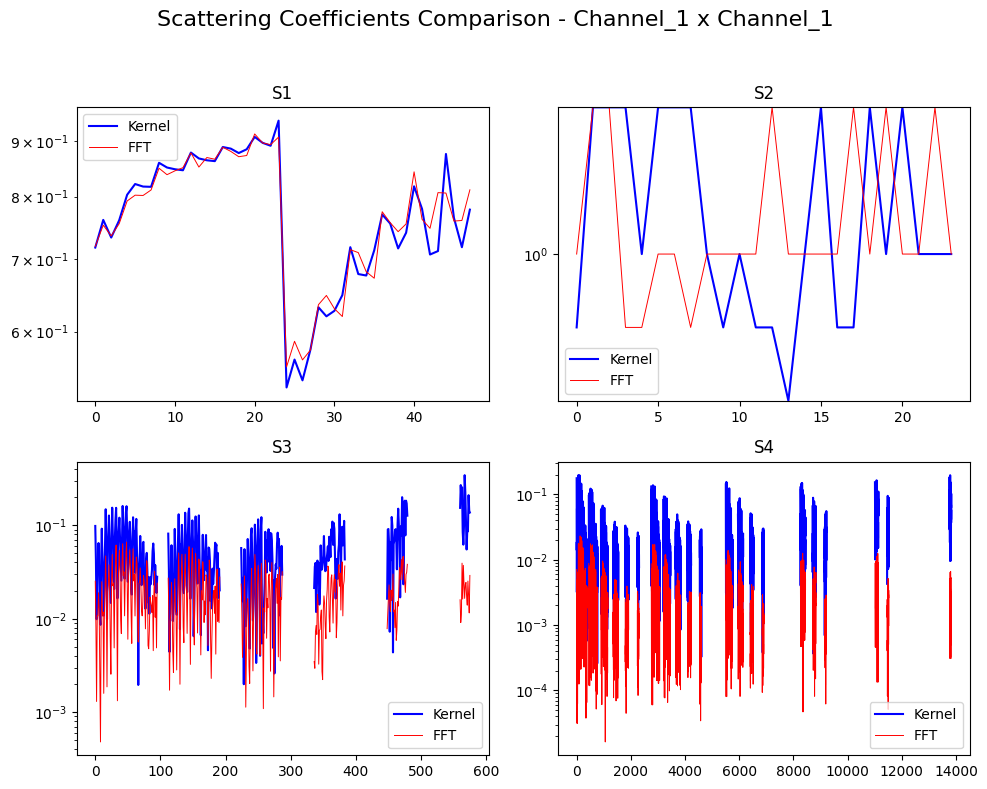

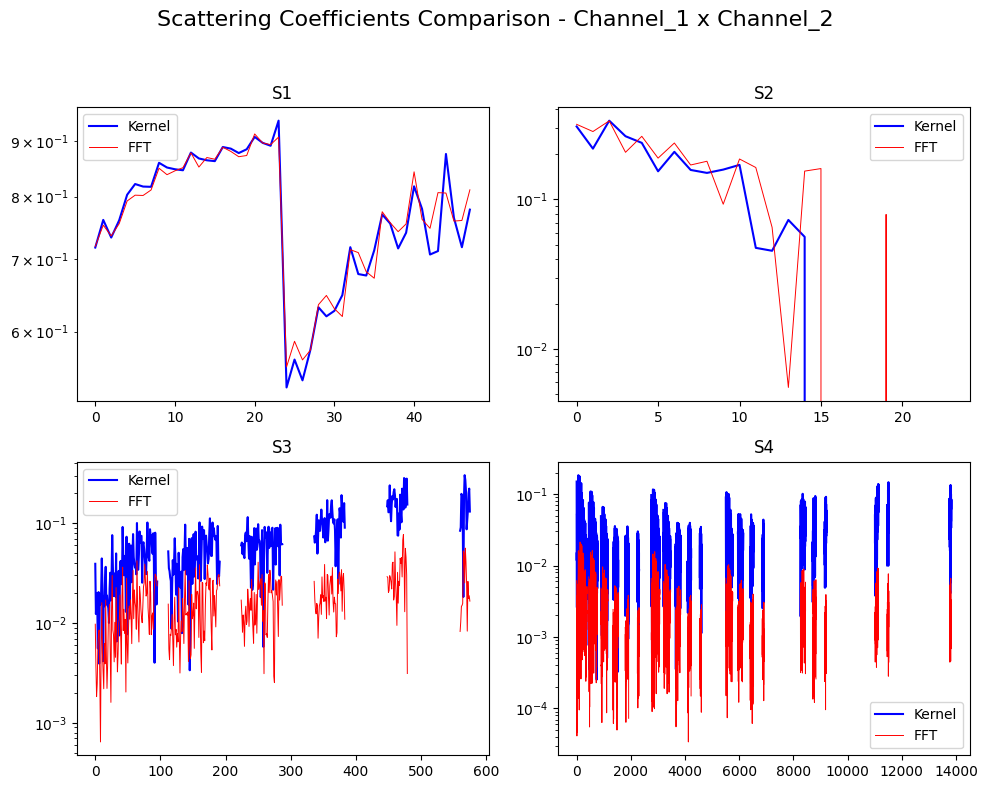

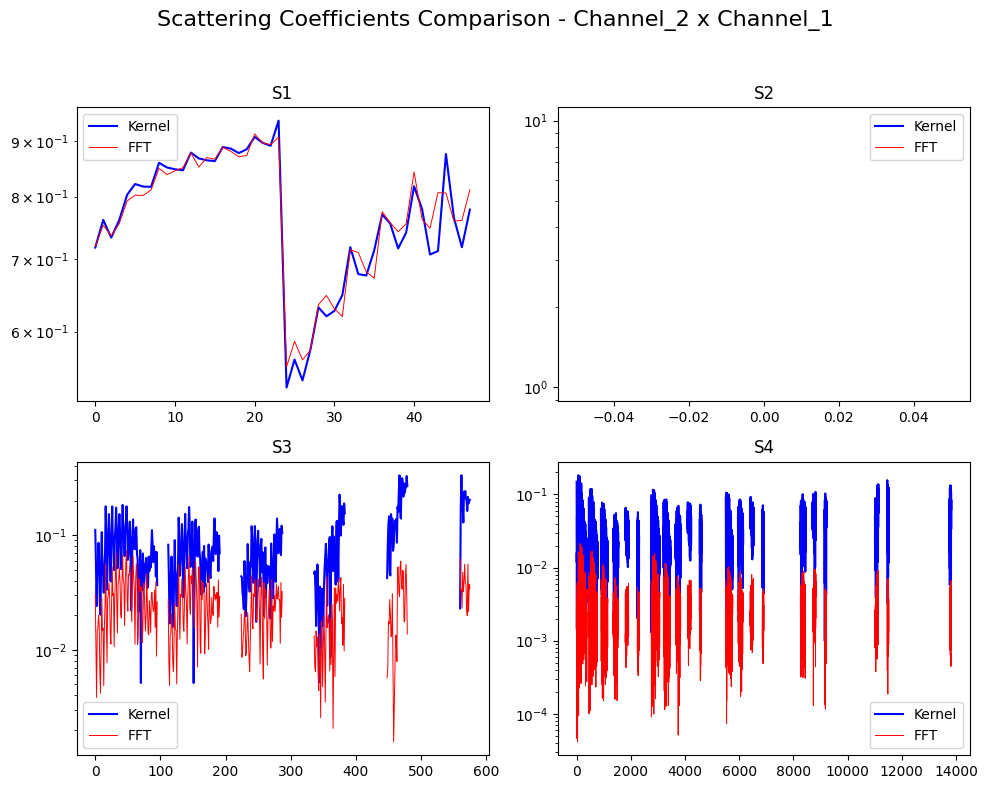

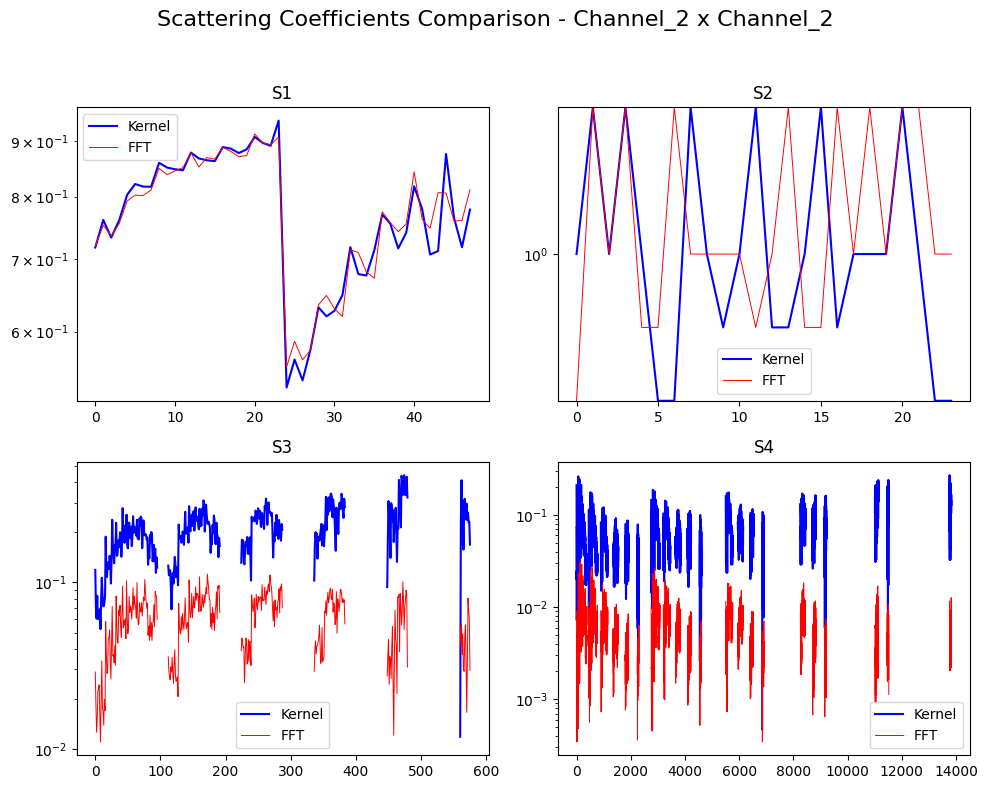

In [ ]:
# Instantiate kernel and FFT dataclass on the multi-channel image
data_kernel_multi_channel = STL_2D_Kernel_Torch(im_multi_channel, pbc=True)
data_fft_multi_channel = STL_2D_FFT_Torch(im_multi_channel, pbc=True)

# Get ST operator
st_op_kernel_multi_channel = data_kernel_multi_channel.get_ST_op()
st_op_fft_multi_channel = data_fft_multi_channel.get_ST_op()

# Apply
compute_cross_matrix = torch.tensor([[1, 1], [0, 1]], dtype=torch.bool)
st_data_kernel_multi_channel = st_op_kernel_multi_channel.apply(data_kernel_multi_channel, compute_cross_matrix=compute_cross_matrix)
st_data_fft_multi_channel = st_op_fft_multi_channel.apply(data_fft_multi_channel, compute_cross_matrix=compute_cross_matrix)

# Plot
for c1 in range(im_multi_channel.shape[0]):
    for c2 in range(im_multi_channel.shape[0]):

        st_data_kernel_multi_channel_sliced = SimpleNamespace(
            S1=st_data_kernel_multi_channel.S1,
            S2=st_data_kernel_multi_channel.S2[:, c1, c2, ...],
            S3=st_data_kernel_multi_channel.S3[:, c1, c2, ...],
            S4=st_data_kernel_multi_channel.S4[:, c1, c2, ...],
        )

        st_data_fft_multi_channel_sliced = SimpleNamespace(
            S1=st_data_fft_multi_channel.S1,
            S2=st_data_fft_multi_channel.S2[:, c1, c2, ...],
            S3=st_data_fft_multi_channel.S3[:, c1, c2, ...],
            S4=st_data_fft_multi_channel.S4[:, c1, c2, ...],
        )

        plot_scattering_coeffs(
                st_data_kernel_multi_channel_sliced,
                st_data_fft_multi_channel_sliced,
                suptitle=f"Scattering Coefficients Comparison - Channel_{c1+1} x Channel_{c2+1}",
                label_st_data1="Kernel",
                label_st_data2="FFT"
        )

We can note that the plot of the **S2** statistic (for the channel pair *channel2 × channel1*) is empty because `S2(c2, c1)` corresponds to the complex conjugate of `S2(c1, c2)`. Since this information is redundant, we compute it only for `S2(c1, c2)`.

### 2. Not PBC - No Mask

There are several ways to handle non-PBC data.  
First, the data are convolved with wavelets, and cropping is applied when computing the mean or covariance.

- **Fully flexible:** the border size is computed to retain as many pixels as possible, based on the involved scale *j* and the convolution depth (i.e., the number of applied wavelets).
- **Largest-scale layer flexible:** the border size is computed conservatively with respect to the largest scale *J*, but it may be adapted to the convolution depth.
- **Largest-scale second layer:** the border size is computed in the most conservative way, using the largest scale *J* and a convolution depth of 2. In this case, all coefficients are estimated on the same set of pixels.


#### 2.1 Kernel (PBC vs Not PBC)

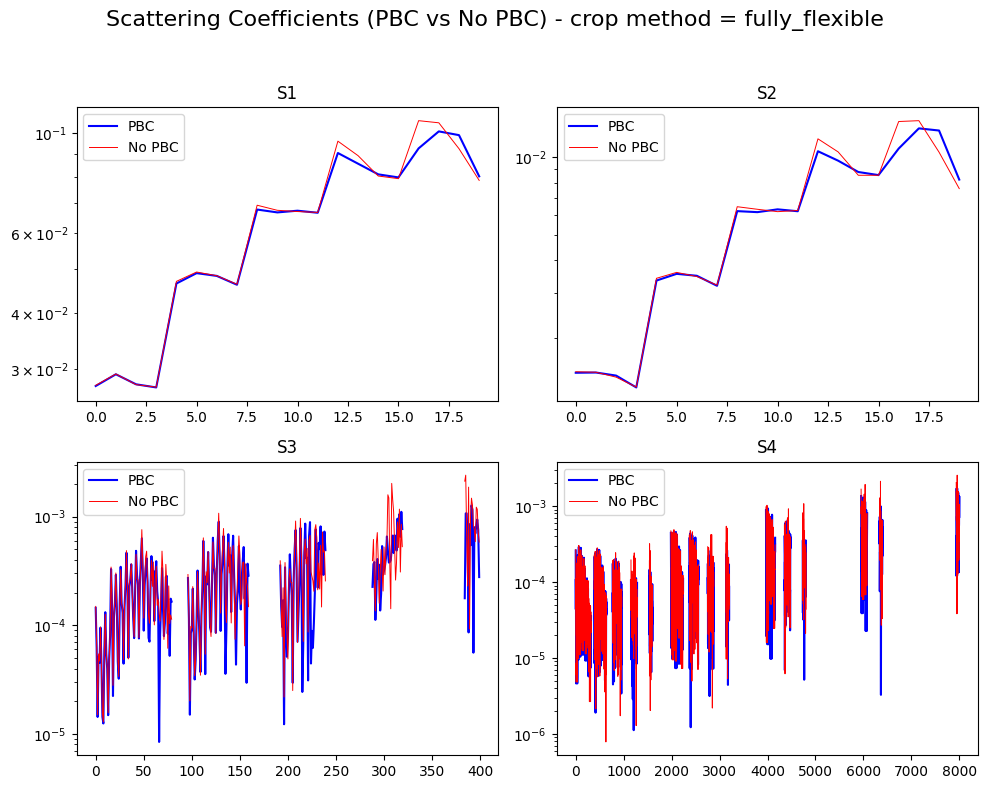

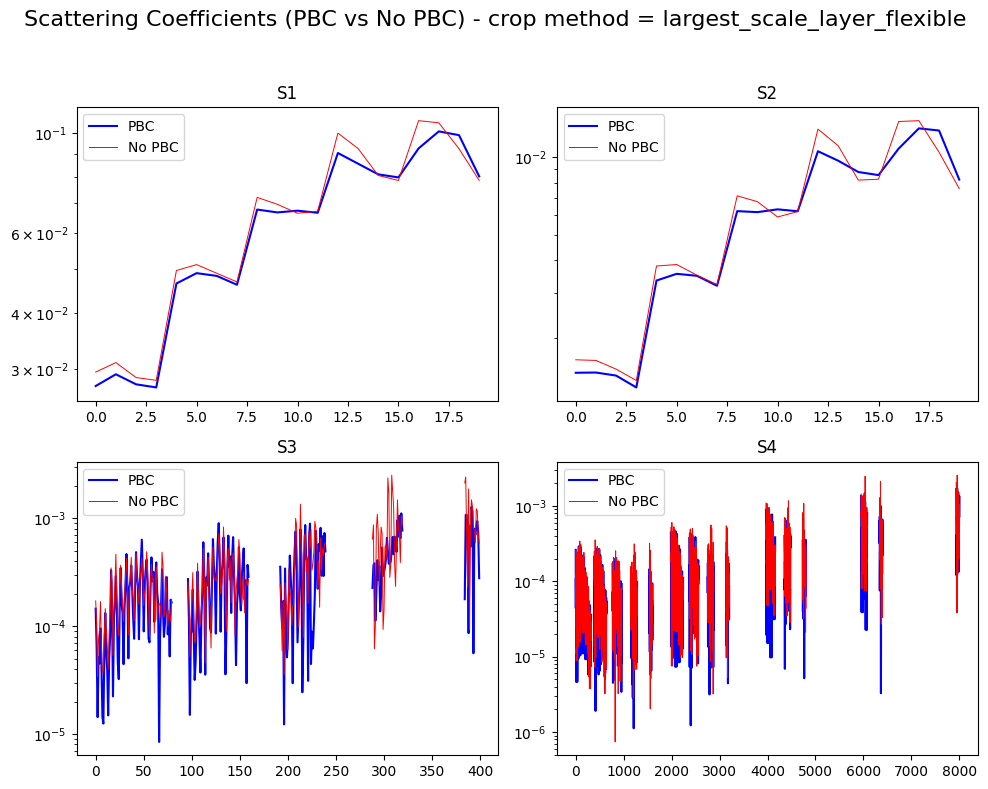

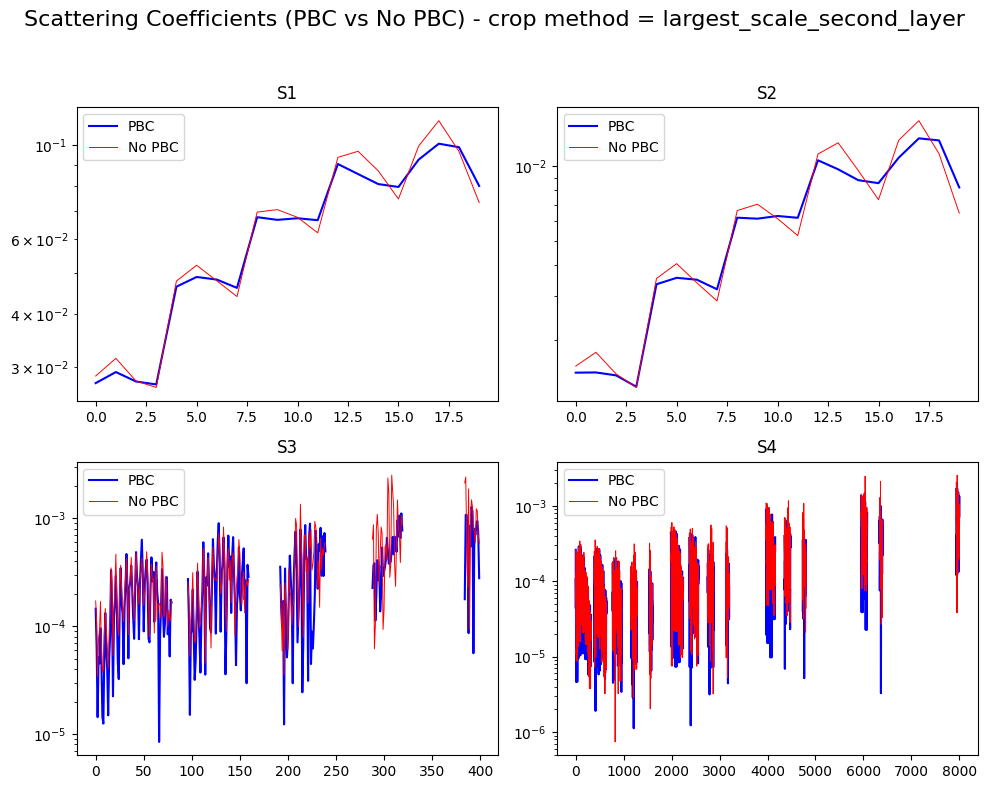

In [ ]:
# Instantiate kernel data class (pbc and no pbc)
data_kernel_pbc = STL_2D_Kernel_Torch(array=im[0,0], pbc=True)
data_kernel_no_pbc = STL_2D_Kernel_Torch(array=im[0,0], pbc=False)

# Liste des méthodes à tester
methods = [
    ("fully_flexible", WaveletOperator2Dkernel_torch._get_crop_border_size_fully_flexible),
    ("largest_scale_layer_flexible", WaveletOperator2Dkernel_torch._get_crop_border_size_largest_scale_layer_flexible),
    ("largest_scale_second_layer", WaveletOperator2Dkernel_torch._get_crop_border_size_largest_scale_second_layer),
]

for name, method in methods:

    # Get ST operator
    st_op_kernel = data_kernel_pbc.get_ST_op(J=5, get_crop_border_size_method=method)

    # Apply
    st_data_kernel_pbc = st_op_kernel.apply(data_kernel_pbc, norm='vanilla')
    st_data_kernel_no_pbc = st_op_kernel.apply(data_kernel_no_pbc, norm='vanilla')

    # Plot
    plot_scattering_coeffs(
        st_data_kernel_pbc,
        st_data_kernel_no_pbc,
        suptitle=f'Scattering Coefficients (PBC vs No PBC) - crop method = {name}',
        label_st_data1='PBC',
        label_st_data2='No PBC'
    )

#### 2.2 FFT (PBC vs Not PBC) 

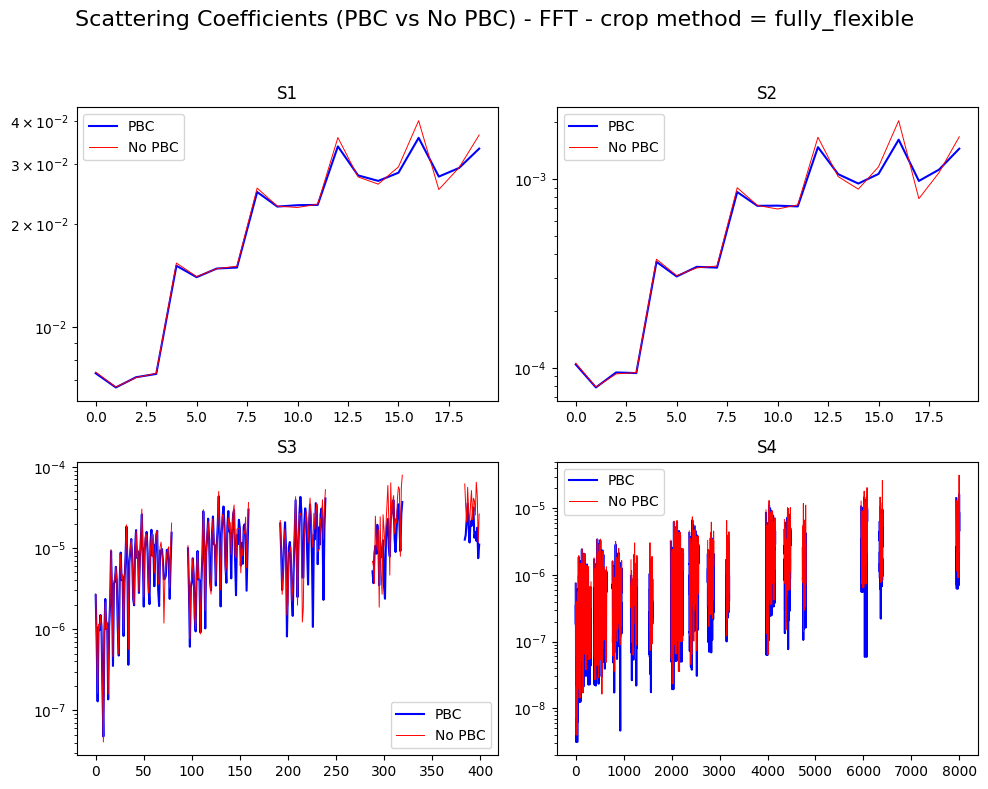

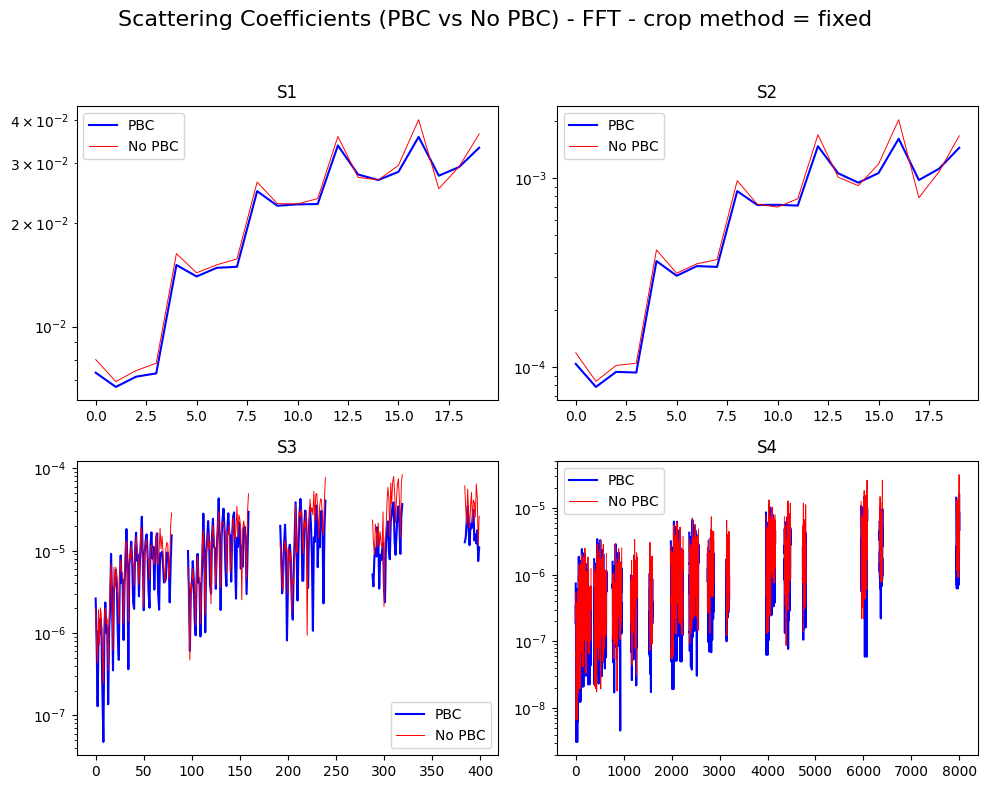

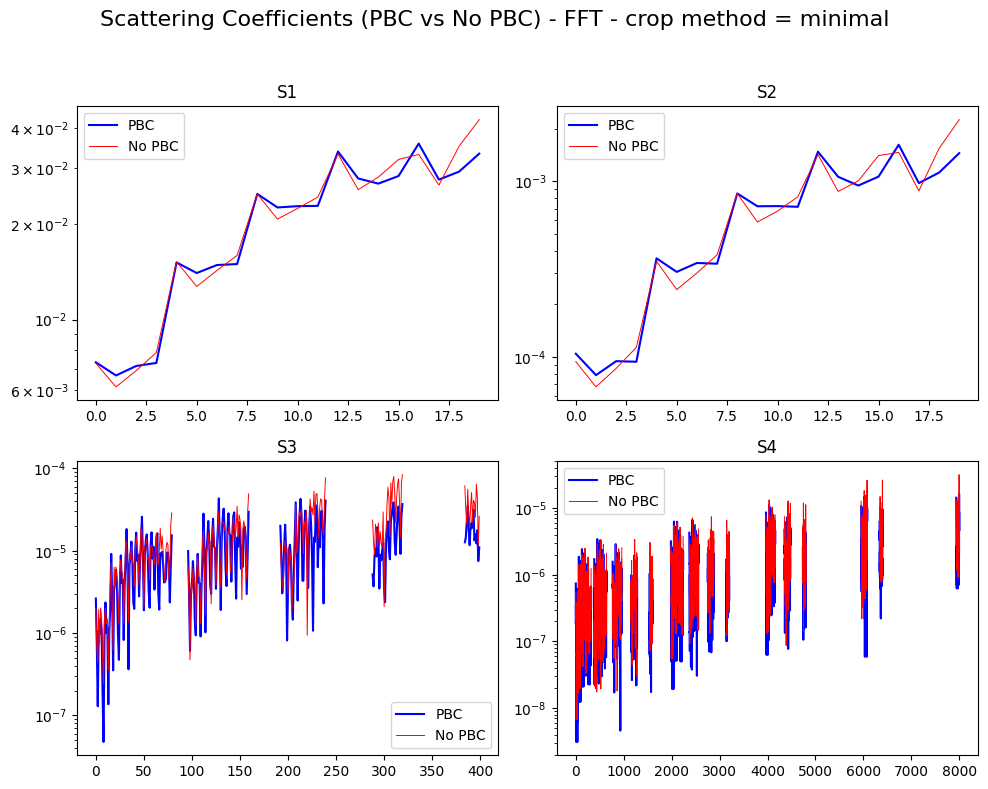

In [ ]:
from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch, WaveletOperator2D_FFT_torch

# Instantiate kernel data class (pbc and no pbc)
data_fft_pbc = STL_2D_FFT_Torch(array=im[0,0], pbc=True)
data_fft_no_pbc = STL_2D_FFT_Torch(array=im[0,0], pbc=False)

# Liste des méthodes à tester
methods = [
    ("fully_flexible", WaveletOperator2D_FFT_torch._get_crop_border_size_fully_flexible),
    ("largest_scale_layer_flexible", WaveletOperator2D_FFT_torch._get_crop_border_size_largest_scale_layer_flexible),
    ("largest_scale_second_layer", WaveletOperator2D_FFT_torch._get_crop_border_size_largest_scale_second_layer),
]

for name, method in methods:

    # Get ST operator
    st_op_fft = data_fft_pbc.get_ST_op(J = 5, WType = "Bump-Steerable", get_crop_border_size_method=method)

    # Apply
    st_data_fft_pbc = st_op_fft.apply(data_fft_pbc, norm='vanilla')
    st_data_fft_no_pbc = st_op_fft.apply(data_fft_no_pbc, norm='vanilla')

    # Plot
    plot_scattering_coeffs(
        st_data_fft_pbc,
        st_data_fft_no_pbc,
        suptitle=f'Scattering Coefficients (PBC vs No PBC) - FFT - crop method = {name}',
        label_st_data1='PBC',
        label_st_data2='No PBC'
    )

### 3. PBC - Mask

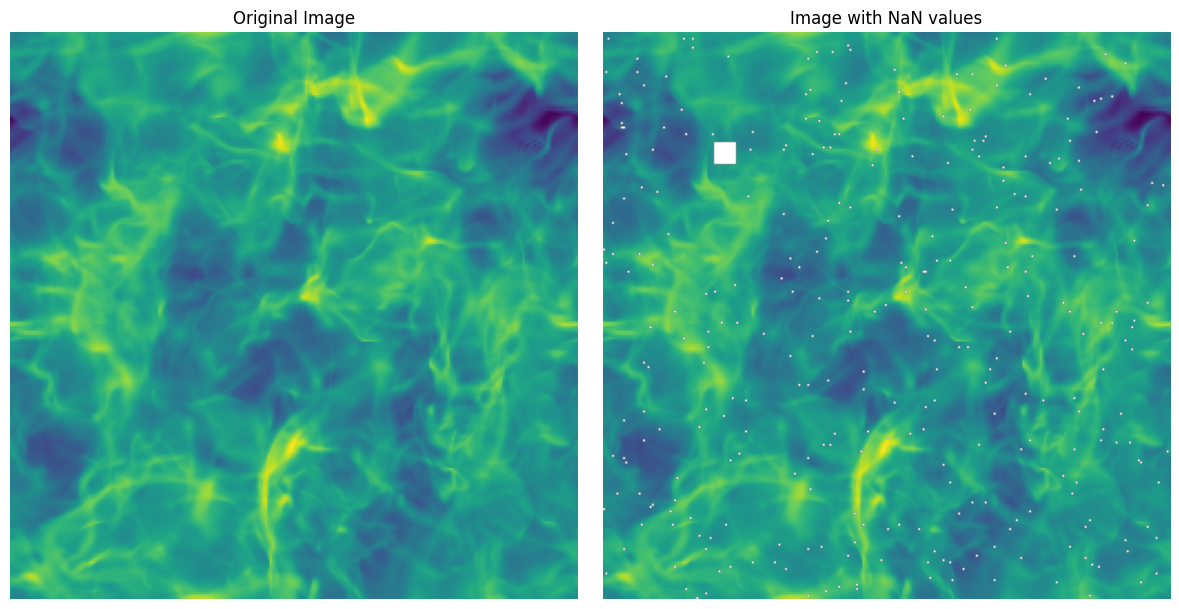

In [24]:
im_nan = im.copy()

np.random.seed(27)

# 300 random NaN value pixels
nan_rows = (np.random.rand(300) * im_nan.shape[0]).astype(int)
nan_cols = (np.random.rand(300) * im_nan.shape[1]).astype(int)
im_nan[nan_rows, nan_cols] = np.nan

# Add a 10x10 block of NaN values
im_nan[50:60, 50:60] = np.nan

# Visualize original and NaN images
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(im, cmap='viridis')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(im_nan, cmap='viridis')
plt.title("Image with NaN values")
plt.axis("off")

plt.tight_layout()
plt.show()

#### 3.1 Kernel (Withous vs With NaNs)

Masked data can only be processed using the Kernel data class.

In [28]:
# Instantiate kernel data class (without and with NaN values)
data = STL_2D_Kernel_Torch(im, pbc=True)
data_nan = STL_2D_Kernel_Torch(im_nan, pbc=True)

# get a ST operator from the data class
st_op = data.get_ST_op()
st_op_nan = data_nan.get_ST_op()

# apply the ST operator to the data
st_data = st_op.apply(data, norm='vanilla')
st_data_nan = st_op_nan.apply(data_nan, norm='vanilla')

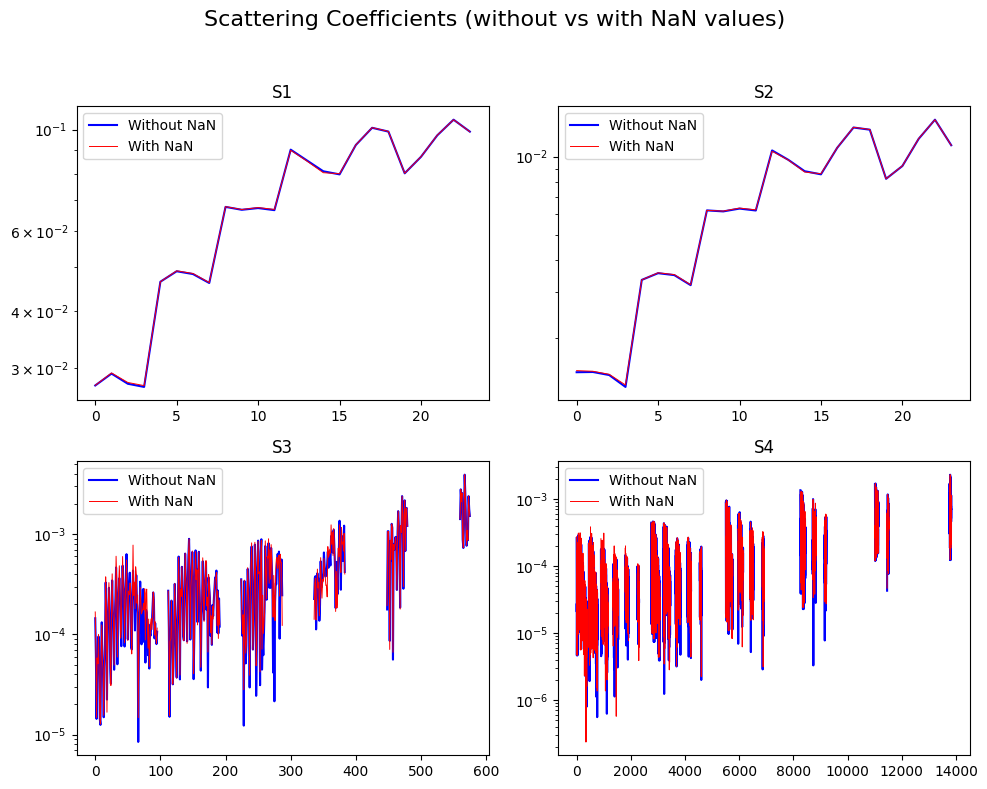

In [29]:
# Plot
plot_scattering_coeffs(
    st_data,
    st_data_nan,
    suptitle='Scattering Coefficients (without vs with NaN values)',
    label_st_data1='Without NaN',
    label_st_data2='With NaN'
)

## Synthesis

| Category | Input image(s) | Output image(s) | Channel(s) | Method(s) |
|----------|---------------|-----------------|---------|--------|
| One → One | 1 PBC image | 1 PBC image | Mono + Cross | Kernel + FFT |
| Many → One | N PBC images | 1 PBC image | Mono | Kernel + FFT |
| One → Many | 1 PBC image | N PBC images | Mono | Kernel + FFT |
| Many → Many | N PBC images | M PBC images | Mono | Kernel + FFT |
| PBC → Non PBC | 1 PBC image | 1 non-PBC image | Mono | Kernel + FFT |
| Non PBC → PBC | 1 non-PBC image | 1 PBC image | Mono | Kernel + FFT |
| Non PBC → Non PBC | 1 non-PBC image | 1 non-PBC image | Mono | Kernel + FFT |
| NaNs → NaNs | 1 image with NaNs | 1 image with NaNs | Mono | Kernel |
| NaNs → NaNs (≠ Mask)| 1 image with NaNs  | 1 image with NaNs | Mono | Kernel |
| Non NaNs → NaNs | 1 image without NaNs | 1 image with NaNs | Mono | Kernel |
| NaNs → Non NaNs | 1 image with NaNs | 1 image without NaNs | Mono | Kernel |


#### One → One 

#### Many → One

#### One → Many

#### Many → Many

#### PBC → Non PBC

#### Non PBC → PBC

#### Non PBC → Non PBC

#### NaNs → NaNs

#### NaNs → NaNs (≠ Mask)

#### Non NaNs → NaNs

#### NaNs → Non NaNs